     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sampled comments: 5000


100%|██████████| 5000/5000 [00:00<00:00, 6094.00it/s]

100%|██████████| 4919/4919 [00:00<00:00, 6178.58it/s]


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Topic 0 → Politics
Topic 1 → Society
Topic 2 → Politics
Topic 3 → Society
Topic 4 → Politics
Topic 5 → Economy


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipython-input-1044313110.py:133: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.scatterplot(


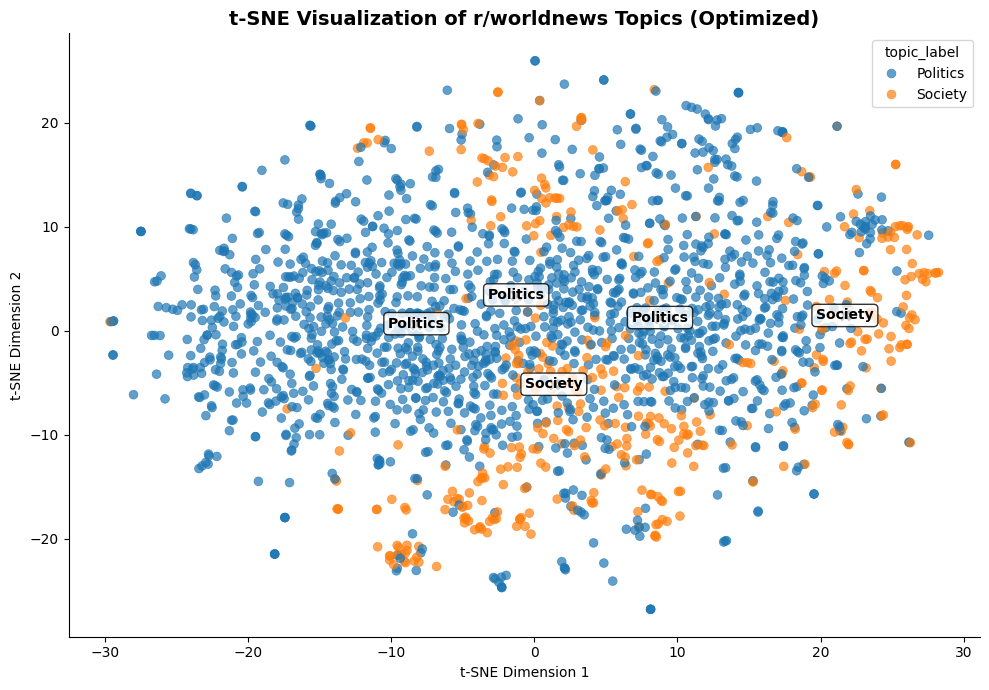


Topic Summary:


,Topic ID,Auto Label,Top Words
0,0,Politics,people would like trump report said government...
1,1,Society,dont lol hes thats youre say like get gon know
2,2,Politics,trump barr mueller like dont russia people kno...
3,3,Society,people get milk like one would dont oil thats ...
4,4,Politics,people dont like think would know get thats tr...
5,5,Economy,cop


In [1]:
# =========================================================
# 🚀 1. INSTALL & IMPORT LIBRARIES
# =========================================================
!pip install fasttext pandas numpy scikit-learn nltk matplotlib seaborn tqdm transformers torch --quiet

import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import fasttext, fasttext.util
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from transformers import pipeline
from functools import lru_cache

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# =========================================================
# 💾 2. LOAD AND SAMPLE DATASET
# =========================================================
df = pd.read_csv("/content/kaggle_RC_2019-05.csv", low_memory=False)
df = df[df['subreddit'].str.lower() == 'worldnews']
df = df.sample(5000, random_state=7)   # ⚡ reduce to 5k rows for speed
print("Sampled comments:", len(df))

# =========================================================
# 🧹 3. CLEAN TEXT
# =========================================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text): return ""
    text = text.lower()
    if "removed" in text or "deleted" in text: return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = [w for w in word_tokenize(text) if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

tqdm.pandas()
df['clean_comment'] = df['body'].progress_apply(clean_text)
df = df[df['clean_comment'].str.strip() != ""]

# =========================================================
# 🔤 4. GENERATE fastText EMBEDDINGS (with caching)
# =========================================================
fasttext.util.download_model('en', if_exists='ignore')
ft = fasttext.load_model('cc.en.300.bin')

@lru_cache(maxsize=None)
def word_vec_cached(w):
    return ft.get_word_vector(w)

def get_vector(text):
    words = text.split()
    if not words: return np.zeros(300)
    return np.mean([word_vec_cached(w) for w in words], axis=0)

tqdm.pandas()
df['vector'] = df['clean_comment'].progress_apply(get_vector)

# =========================================================
# 🧩 5. K-MEANS CLUSTERING
# =========================================================
X = np.vstack(df['vector'].values)
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['topic'] = kmeans.fit_predict(X)

# =========================================================
# 🔍 6. EXTRACT TOP WORDS PER TOPIC
# =========================================================
def top_words(topic_num, n=15):
    text = " ".join(df[df['topic']==topic_num]['clean_comment'])
    return [w for w, _ in Counter(text.split()).most_common(n)]

topic_words = {i: top_words(i) for i in range(n_clusters)}
for k, v in topic_words.items():
    print(f"\nTopic {k}: {v[:10]}")

# =========================================================
# 🧠 7. ZERO-SHOT LABELING WITH BART-LARGE-MNLI
# =========================================================
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = [
    "Politics", "Economy", "War and Conflict", "Climate Change",
    "Technology", "Human Rights", "Elections", "Society", "Environment"
]

topic_labels = {}
for topic, words in topic_words.items():
    text = " ".join(words[:10])
    result = classifier(text, candidate_labels)
    topic_labels[topic] = result['labels'][0]
    print(f"Topic {topic} → {result['labels'][0]}")

# =========================================================
# 📊 8. FAST t-SNE (sampled 2k for speed)
# =========================================================
df_subset = df.sample(2000, random_state=42)
X_subset = np.vstack(df_subset['vector'].values)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=750,
    learning_rate='auto'
)
X_tsne = tsne.fit_transform(X_subset)

df_subset['x'] = X_tsne[:, 0]
df_subset['y'] = X_tsne[:, 1]
df_subset['topic_label'] = df_subset['topic'].map(topic_labels)

# =========================================================
# 🌈 9. ANNOTATED t-SNE VISUALIZATION
# =========================================================
plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", n_clusters)

sns.scatterplot(
    data=df_subset,
    x='x', y='y',
    hue='topic_label',
    palette=palette,
    s=40, alpha=0.7, edgecolor=None
)

# Add centroids + labels
for i in range(n_clusters):
    subset = df_subset[df_subset['topic'] == i]
    x, y = subset['x'].mean(), subset['y'].mean()
    plt.scatter(x, y, c='black', s=100, marker='X', edgecolors='white')
    plt.text(
        x, y,
        topic_labels[i],
        fontsize=10, weight='bold', ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3')
    )

plt.title("t-SNE Visualization of r/worldnews Topics (Optimized)", fontsize=14, weight='bold')
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
sns.despine()
plt.show()

# =========================================================
# 🧾 10. TOPIC SUMMARY TABLE
# =========================================================
summary = pd.DataFrame({
    "Topic ID": list(topic_labels.keys()),
    "Auto Label": [topic_labels[i] for i in topic_labels],
    "Top Words": [" ".join(topic_words[i][:10]) for i in topic_labels]
})
print("\nTopic Summary:")
display(summary)
